In [ ]:
# ── enregistrement automatique des figures ──
# chaque plt.show() écrit aussi un PNG dans figures/data-copernicus/
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "tvfed").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from tvfed.figures import activer

activer("data-copernicus")

In [ ]:
import cdsapi, time
from pathlib import Path

client = cdsapi.Client()
OUT = Path("../data/copernicus/raw/cems"); OUT.mkdir(parents=True, exist_ok=True)

VARIABLES = [
    "fire_weather_index",           # référence EFFIS / IFM Météo-France
    "fine_fuel_moisture_code",      # mémoire ~1 j
    "duff_moisture_code",           # mémoire 12 j
    "drought_code",                 # mémoire 52 j
    "build_up_index",               # f(DMC, DC)
    "initial_fire_spread_index",    # f(FFMC, vent) — seul porteur du vent
    "keetch_byram_drought_index",   # AU — sécheresse sol
    "energy_release_component",     # US — intensité potentielle
]
AREA = [51.3, -5.1, 41.35, 9.4]   # [N, O, S, E] France + Corse

def build_request(year, dataset_type):
    return {
        "product_type":   "reanalysis",
        "dataset_type":   dataset_type,
        "system_version": ["4_1"],
        "variable":       VARIABLES,
        "year":           [str(year)],
        "month":          [f"{m:02d}" for m in range(1, 13)],
        "day":            [f"{d:02d}" for d in range(1, 32)],
        "grid":           "0.25/0.25",
        "data_format":    "netcdf",
        "area":           AREA,
    }

echecs = []
for year in range(1973, 2027):
    target = OUT / f"cems_fire_{year}.nc"
    if target.exists() and target.stat().st_size > 0:
        print(f"⏭️  {year} — déjà présent")
        continue

    t0, err = time.time(), None
    for dtype in ("consolidated_dataset", "intermediate_dataset"):
        try:
            client.retrieve("cems-fire-historical-v1", build_request(year, dtype), str(target))
            print(f"✅ {year} [{dtype}] — {target.stat().st_size/1e6:.0f} Mo en {time.time()-t0:.0f}s")
            break
        except Exception as e:
            target.unlink(missing_ok=True)          # pas de .nc tronqué qui ferait croire à un succès
            err = str(e).splitlines()[0][:150]
    else:
        print(f"❌ {year} — {err}")
        echecs.append(year)

print(f"\n{'—'*60}\nTerminé. Échecs : {echecs or 'aucun'}")

2026-07-16 21:59:39,729 INFO Request ID is 00ae8a7b-7683-4d07-bf3b-84473a3d76d6
2026-07-16 21:59:41,038 INFO status has been updated to accepted
2026-07-16 22:00:13,795 INFO status has been updated to successful


✅ 1973 [consolidated_dataset] — 12 Mo en 38s


2026-07-16 22:00:18,506 INFO Request ID is 695b0361-70f2-49bf-8ff4-89e2dbc58f2f
2026-07-16 22:00:18,547 INFO status has been updated to accepted
2026-07-16 22:00:53,405 INFO status has been updated to running
2026-07-16 22:03:13,186 INFO status has been updated to successful


✅ 1974 [consolidated_dataset] — 12 Mo en 178s


2026-07-16 22:03:17,428 INFO Request ID is d3b4e39d-f678-44e5-ba7a-e93edf8ce885
2026-07-16 22:03:17,466 INFO status has been updated to accepted
2026-07-16 22:03:31,886 INFO status has been updated to running
2026-07-16 22:15:42,532 INFO status has been updated to successful
2026-07-16 22:15:43,341 INFO Request ID is 04bffc8a-27cd-4b17-9767-34dea6966843          


...

2026-07-16 23:58:40,763 INFO Request ID is dbd14ef6-04e0-4597-816a-4554c106c89b
2026-07-16 23:58:40,812 INFO status has been updated to accepted
2026-07-16 23:59:15,448 INFO status has been updated to running
2026-07-17 00:01:35,347 INFO status has been updated to successful


✅ 2025 [consolidated_dataset] — 12 Mo en 176s


2026-07-17 00:01:36,308 INFO Request ID is 1262fc50-6b7a-4572-b3a4-ca925b13a022
2026-07-17 00:01:38,183 INFO status has been updated to accepted
2026-07-17 00:02:28,003 INFO status has been updated to running
2026-07-17 00:03:32,360 INFO status has been updated to successful
                                                                                         

✅ 2026 [consolidated_dataset] — 3 Mo en 117s

————————————————————————————————————————————————————————————
Terminé. Échecs : aucun


: 

In [2]:
import xarray as xr

ds = xr.open_dataset("../data/copernicus/raw/cems/cems_fire_2006.nc")
print(ds)                       # ⚠️ les noms réels ≠ noms de la requête
print("\nVariables :", list(ds.data_vars))

<xarray.Dataset> Size: 28MB
Dimensions:     (valid_time: 365, latitude: 40, longitude: 59)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2006-01-01 ... 2006-12-31
  * latitude    (latitude) float64 320B 51.1 50.85 50.6 ... 41.85 41.6 41.35
  * longitude   (longitude) float64 472B -5.1 -4.85 -4.6 -4.35 ... 8.9 9.15 9.4
    surface     float64 8B ...
Data variables:
    fwinx       (valid_time, latitude, longitude) float32 3MB ...
    ffmcode     (valid_time, latitude, longitude) float32 3MB ...
    dufmcode    (valid_time, latitude, longitude) float32 3MB ...
    drtcode     (valid_time, latitude, longitude) float32 3MB ...
    fbupinx     (valid_time, latitude, longitude) float32 3MB ...
    infsinx     (valid_time, latitude, longitude) float32 3MB ...
    kbdi        (valid_time, latitude, longitude) float32 3MB ...
    ercnfdr     (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_cent

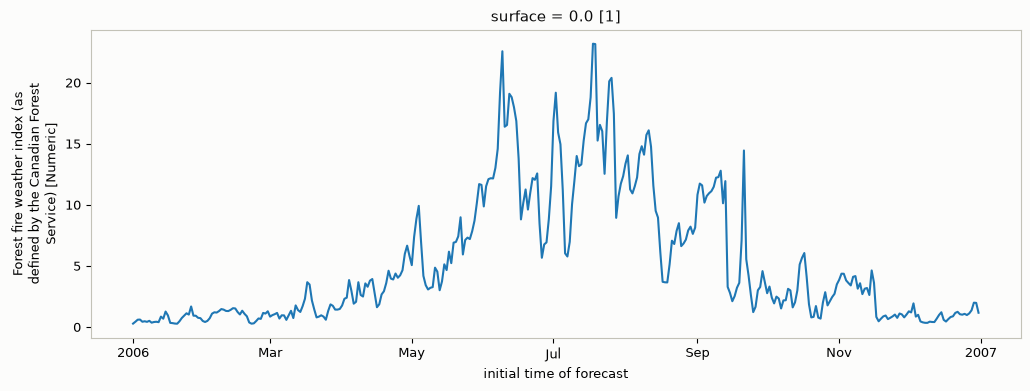

In [3]:
from matplotlib import pyplot as plt

var = list(ds.data_vars)[0]
ds[var].mean(dim=["latitude", "longitude"]).plot(figsize=(12, 4))
# pic estival net = OK  |  courbe plate = problème

📂 53 fichiers — c:\Users\romua\Documents\La_Plateforme_\Projet 1 - TERRE FEU VENT EAU DATA\terre-vent-feu-eau-data\data\copernicus\raw\cems

══════════════════════════════════════════════════════════════
📦 INVENTAIRE — 53 fichiers, 643 Mo, 1973 → 2025
══════════════════════════════════════════════════════════════
  variables par fichier : [8]   ✅
  grille                : ['40x59']   ✅
  années complètes      : ✅ toutes

══════════════════════════════════════════════════════════════
🕐 AXE TEMPOREL
══════════════════════════════════════════════════════════════
  pas de temps      : 19,358 | 1973-01-01 → 2025-12-31
  doublons de dates : 0  ✅
  dates manquantes  : 0  ✅
  bissextiles à 366j: 13/13  ✅

══════════════════════════════════════════════════════════════
🕳️  VALEURS MANQUANTES
══════════════════════════════════════════════════════════════
  cellules de la grille   : 2360
  toujours NaN (= mer)    : 410 (17.4%)
  terre exploitable       : 1950 (82.6%)
  masque stable 1973→2025 : ✅ 

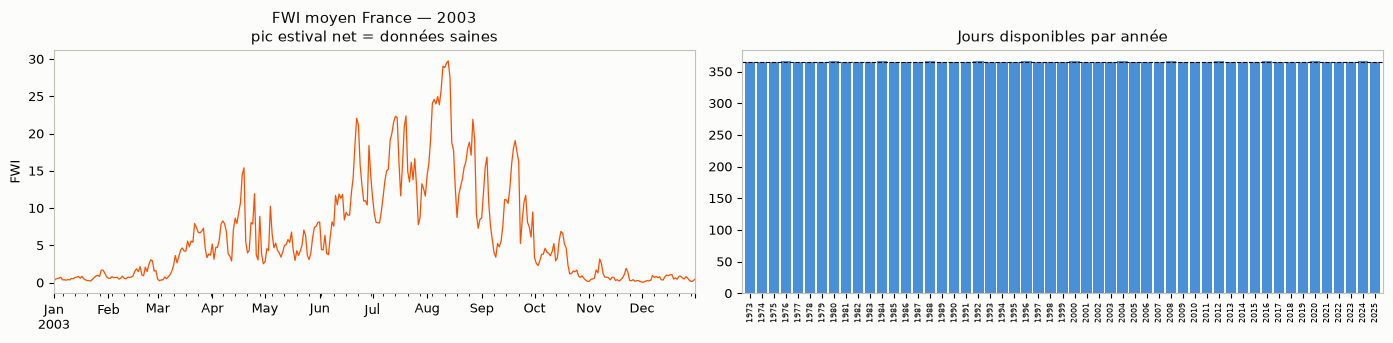


══════════════════════════════════════════════════════════════
VERDICT
══════════════════════════════════════════════════════════════
  ✅ Aucun problème de qualité détecté.


In [4]:
import xarray as xr, numpy as np, pandas as pd
import calendar
from pathlib import Path
import matplotlib.pyplot as plt

# Marche que la cellule tourne depuis notebook/ ou depuis la racine du repo :
# on remonte l'arborescence jusqu'à trouver le dossier des données.
SOUS_CHEMIN = "data/copernicus/raw/cems"
racines = [p for p in (Path.cwd(), *Path.cwd().parents) if (p / SOUS_CHEMIN).is_dir()]
if not racines:
    raise FileNotFoundError(f"'{SOUS_CHEMIN}' introuvable depuis {Path.cwd()} ni dans ses parents.")
CEMS_DIR = racines[0] / SOUS_CHEMIN
CEMS = sorted(CEMS_DIR.glob("*.nc"))
if not CEMS:
    raise FileNotFoundError(f"Aucun .nc dans {CEMS_DIR}")   # échouer ICI, pas 30 lignes plus bas
print(f"📂 {len(CEMS)} fichiers — {CEMS_DIR}\n")

NOMS = {   # ⚠️ les noms dans le NetCDF ne sont PAS ceux de la requête API
    "fwinx": "FWI", "ffmcode": "FFMC", "dufmcode": "DMC", "drtcode": "DC",
    "fbupinx": "BUI", "infsinx": "ISI", "kbdi": "KBDI", "ercnfdr": "ERC",
}
# Bornes annoncées par la doc CEMS — on va les confronter au réel
DOC = {"FWI": (0, 100), "FFMC": (0, 99), "DMC": (0, None), "DC": (0, 800),
       "BUI": (0, None), "ISI": (0, None), "KBDI": (0, 200), "ERC": (0, None)}

# ════════════════════════════════════════════════════════════════
# 1. INVENTAIRE & COHÉRENCE STRUCTURELLE
# ════════════════════════════════════════════════════════════════
lignes, masques, temps, stats = [], {}, [], []
for f in CEMS:
    annee = int(f.stem.split("_")[-1])          # cems_fire_1973.nc -> 1973
    with xr.open_dataset(f) as ds:
        t = pd.to_datetime(ds.valid_time.values)
        temps.append(t)
        masques[annee] = ds.fwinx.isnull().all(dim="valid_time").values   # candidat "mer"
        lignes.append({
            "annee": annee, "jours": len(t),
            "attendu": 366 if calendar.isleap(annee) else 365,
            "n_vars": len(ds.data_vars),
            "grille": f"{ds.sizes['latitude']}x{ds.sizes['longitude']}",
            "Mo": f.stat().st_size / 1e6,
        })
        for v, nom in NOMS.items():
            a = ds[v].values
            a = a[~np.isnan(a)]
            stats.append({"annee": annee, "var": nom, "min": a.min(), "max": a.max(),
                          "moy": a.mean(), "nan_pct": float(ds[v].isnull().mean()) * 100})

rapport = pd.DataFrame(lignes)
rapport["complet"] = rapport.jours == rapport.attendu
stats = pd.DataFrame(stats)

print("═" * 62)
print(f"📦 INVENTAIRE — {len(rapport)} fichiers, {rapport.Mo.sum():.0f} Mo, "
      f"{rapport.annee.min()} → {rapport.annee.max()}")
print("═" * 62)
print(f"  variables par fichier : {rapport.n_vars.unique().tolist()}   {'✅' if rapport.n_vars.nunique() == 1 else '❌ HÉTÉROGÈNE'}")
print(f"  grille                : {rapport.grille.unique().tolist()}   {'✅' if rapport.grille.nunique() == 1 else '❌ HÉTÉROGÈNE'}")

incomplets = rapport[~rapport.complet]
if len(incomplets):
    print(f"\n  ⚠️  Années incomplètes :")
    for _, r in incomplets.iterrows():
        print(f"      {r.annee} : {r.jours} j / {r.attendu} attendus  ({r.attendu - r.jours} manquants)")
else:
    print("  années complètes      : ✅ toutes")

# ════════════════════════════════════════════════════════════════
# 2. AXE TEMPOREL — doublons, trous, bissextiles
# ════════════════════════════════════════════════════════════════
t = pd.DatetimeIndex(np.concatenate([x.values for x in temps])).sort_values()
plage = pd.date_range(t[0], t[-1], freq="D")
manquantes = plage.difference(t)
doublons = t[t.duplicated()]
biss = rapport[rapport.annee.map(calendar.isleap)]

print("\n" + "═" * 62)
print("🕐 AXE TEMPOREL")
print("═" * 62)
print(f"  pas de temps      : {len(t):,} | {t[0].date()} → {t[-1].date()}")
print(f"  doublons de dates : {len(doublons)}  {'✅' if len(doublons) == 0 else '❌'}")
print(f"  dates manquantes  : {len(manquantes)}  {'✅' if len(manquantes) == 0 else '❌'}")
if len(manquantes):
    print(f"      ex. : {list(manquantes[:5].date)}")
print(f"  bissextiles à 366j: {(biss.jours == 366).sum()}/{len(biss)}  "
      f"{'✅' if (biss.jours == 366).all() else '❌ le 29/02 saute quelque part'}")

# ════════════════════════════════════════════════════════════════
# 3. VALEURS MANQUANTES — mer ≠ trou de données
# ════════════════════════════════════════════════════════════════
print("\n" + "═" * 62)
print("🕳️  VALEURS MANQUANTES")
print("═" * 62)

# Le masque "toujours NaN" est-il le même toutes les années ?
ref = masques[rapport.annee.min()]
stable = all(np.array_equal(m, ref) for m in masques.values())
n_mer, n_tot = int(ref.sum()), ref.size

print(f"  cellules de la grille   : {n_tot}")
print(f"  toujours NaN (= mer)    : {n_mer} ({n_mer/n_tot:.1%})")
print(f"  terre exploitable       : {n_tot - n_mer} ({1 - n_mer/n_tot:.1%})")
print(f"  masque stable {rapport.annee.min()}→{rapport.annee.max()} : "
      f"{'✅ identique toutes années' if stable else '❌ le trait de côte bouge !'}")

# LE test qui compte : des NaN qui ne sont PAS la mer ?
with xr.open_dataset(CEMS[len(CEMS) // 2]) as ds:
    n_t = ds.sizes["valid_time"]
    nan_cellule = ds.fwinx.isnull().sum(dim="valid_time").values
    intermittents = int(((nan_cellule > 0) & (nan_cellule < n_t)).sum())
    identiques = all(np.array_equal(np.isnan(ds[v].isel(valid_time=0).values),
                                    np.isnan(ds.fwinx.isel(valid_time=0).values))
                     for v in ds.data_vars)

print(f"\n  ▸ cellules PARFOIS NaN   : {intermittents}   "
      f"{'✅ aucun trou réel — tout NaN est de la mer' if intermittents == 0 else '❌ vrais trous à traiter'}")
print(f"  ▸ masque identique sur les 8 variables : {'✅' if identiques else '❌'}")
print(f"\n  → Le taux de NaN brut ({stats.nan_pct.mean():.1f} %) est un ARTEFACT DE CADRAGE,")
print(f"    pas un défaut de qualité : la bbox France+Corse contient de l'océan.")
print(f"    ⚠️  Ne JAMAIS imputer ces NaN. Masquer la mer, point.")

# ════════════════════════════════════════════════════════════════
# 4. PLAGES PHYSIQUES — la doc CEMS vs le réel
# ════════════════════════════════════════════════════════════════
print("\n" + "═" * 62)
print("📏 PLAGES DE VALEURS (terre uniquement) — réel vs doc")
print("═" * 62)
glob_stats = stats.groupby("var").agg(min=("min", "min"), max=("max", "max"), moy=("moy", "mean"))
glob_stats = glob_stats.reindex(list(NOMS.values()))
print(f"  {'var':6s} {'min':>8s} {'max':>9s} {'moy':>8s}   doc      verdict")
for v, r in glob_stats.iterrows():
    lo, hi = DOC[v]
    depasse = hi is not None and r["max"] > hi
    doc_s = f"{lo}-{hi}" if hi else f"{lo}-∞"
    verdict = f"❌ dépasse la doc de {r['max']-hi:.2f}" if depasse else "✅"
    print(f"  {v:6s} {r['min']:8.2f} {r['max']:9.2f} {r['moy']:8.2f}   {doc_s:8s} {verdict}")
print("\n  → Rappel Plan.md §4.4 : « Fie-toi à df.describe(), pas à la doc. »")

# ════════════════════════════════════════════════════════════════
# 5. SANITY CHECK — le cycle saisonnier doit exister
# ════════════════════════════════════════════════════════════════
temoin = CEMS_DIR / "cems_fire_2003.nc"          # 2003 = canicule, le pic doit crever le plafond
if not temoin.exists():
    temoin = CEMS[len(CEMS) // 2]
with xr.open_dataset(temoin) as ds:
    serie = ds.fwinx.mean(dim=["latitude", "longitude"]).to_pandas()
    an_temoin = int(temoin.stem.split("_")[-1])

fig, ax = plt.subplots(1, 2, figsize=(14, 3.5))
serie.plot(ax=ax[0], lw=.9, color="#FA4F00")
ax[0].set_title(f"FWI moyen France — {an_temoin}\npic estival net = données saines")
ax[0].set_ylabel("FWI"); ax[0].set_xlabel("")

rapport.set_index("annee").jours.plot.bar(ax=ax[1], color="#4A90D9", width=.85)
ax[1].set_title("Jours disponibles par année")
ax[1].axhline(365, color="k", ls="--", lw=.8)
ax[1].set_xlabel(""); ax[1].tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.show()

print("\n" + "═" * 62)
print("VERDICT")
print("═" * 62)
pb = []
if len(doublons): pb.append(f"{len(doublons)} doublons")
if len(manquantes): pb.append(f"{len(manquantes)} dates manquantes")
if intermittents: pb.append(f"{intermittents} cellules à trous")
if not stable: pb.append("masque mer instable")
if rapport.n_vars.nunique() > 1: pb.append("variables hétérogènes")
if rapport.grille.nunique() > 1: pb.append("grilles hétérogènes")
print("  ✅ Aucun problème de qualité détecté." if not pb else "  ❌ " + " · ".join(pb))
if len(incomplets):
    annees = ", ".join(str(a) for a in incomplets.annee)
    print(f"  ℹ️  Réserve : {annees} incomplète(s) — attendu, le consolidé CEMS a ~3 mois de retard.")

In [5]:
"""CELLULE 1 — Masque France + extraction des séries journalières (1 passe sur les 53 fichiers)."""
import xarray as xr, numpy as np, pandas as pd
from pathlib import Path

def _trouve(sous_chemin):
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / sous_chemin).exists():
            return p / sous_chemin
    raise FileNotFoundError(f"'{sous_chemin}' introuvable depuis {Path.cwd()}")

CEMS_DIR = _trouve("data/copernicus/raw/cems")
COMMUNES = _trouve("data/ville-france/communes-france-2026.csv")
CEMS = sorted(CEMS_DIR.glob("*.nc"))
if not CEMS:
    raise FileNotFoundError(f"Aucun .nc dans {CEMS_DIR}")

# ════════════════════════════════════════════════════════════════
# 1. LE MASQUE FRANCE — par snapping des centroïdes de communes
# ════════════════════════════════════════════════════════════════
com = pd.read_csv(
    COMMUNES,
    usecols=["code_insee", "nom_standard", "dep_code", "latitude_centre", "longitude_centre"],
    dtype={"code_insee": str, "dep_code": str},   # ⚠️ sinon '2A'/'2B' cassent le parsing
).dropna(subset=["latitude_centre", "longitude_centre"])

# DOM (971-976) hors bbox européenne -> métropole seule (Corse = 2A/2B incluse)
metro = com[~com.dep_code.str.startswith(("97", "98"), na=False)].copy()

with xr.open_dataset(CEMS[0]) as ds0:
    LATS, LONS = ds0.latitude.values, ds0.longitude.values
    MER = ds0.fwinx.isnull().all(dim="valid_time").values      # True = jamais de valeur = mer

ilat = np.abs(metro.latitude_centre.values[:, None]  - LATS[None, :]).argmin(axis=1)
ilon = np.abs(metro.longitude_centre.values[:, None] - LONS[None, :]).argmin(axis=1)
metro["ilat"], metro["ilon"] = ilat, ilon

MASQUE_FR = np.zeros_like(MER, dtype=bool)
MASQUE_FR[ilat, ilon] = True

MASQUE_CORSE = np.zeros_like(MER, dtype=bool)
co = metro[metro.dep_code.isin(["2A", "2B"])]
MASQUE_CORSE[co.ilat, co.ilon] = True

TERRE = ~MER
print(f"🗺️  MASQUE — grille {MER.shape[0]}x{MER.shape[1]} = {MER.size} cellules")
print(f"    mer (toujours NaN)     : {MER.sum():4d}")
print(f"    terre                  : {TERRE.sum():4d}")
print(f"      dont FRANCE métro    : {MASQUE_FR.sum():4d}   ({metro.code_insee.nunique()} communes)")
print(f"      dont Corse           : {MASQUE_CORSE.sum():4d}   ({co.code_insee.nunique()} communes)")
print(f"      dont étranger        : {(TERRE & ~MASQUE_FR).sum():4d}   (ES, IT, DE, BE, CH, UK…)")
print(f"    communes sur une cellule de mer : {MER[ilat, ilon].sum()}  (doit être 0)")

# ════════════════════════════════════════════════════════════════
# 2. EXTRACTION — moyenne journalière, 2 périmètres
# ════════════════════════════════════════════════════════════════
morceaux = []
for f in CEMS:
    with xr.open_dataset(f) as ds:
        fwi = ds.fwinx.values                       # (t, lat, lon)
        morceaux.append(pd.DataFrame({
            "date":   pd.to_datetime(ds.valid_time.values),
            "bbox":   np.nanmean(np.where(TERRE,        fwi, np.nan), axis=(1, 2)),
            "france": np.nanmean(np.where(MASQUE_FR,    fwi, np.nan), axis=(1, 2)),
            "corse":  np.nanmean(np.where(MASQUE_CORSE, fwi, np.nan), axis=(1, 2)),
        }))

SERIE = pd.concat(morceaux, ignore_index=True).sort_values("date").reset_index(drop=True)
SERIE["annee"] = SERIE.date.dt.year
SERIE["doy"]   = SERIE.date.dt.dayofyear

print(f"\n📈 SÉRIE — {len(SERIE):,} jours, {SERIE.annee.min()} → {SERIE.annee.max()}")
print(SERIE[["bbox", "france", "corse"]].describe().round(2).to_string())

🗺️  MASQUE — grille 40x59 = 2360 cellules
    mer (toujours NaN)     :  410
    terre                  : 1950
      dont FRANCE métro    : 1131   (34734 communes)
      dont Corse           :   22   (360 communes)
      dont étranger        :  819   (ES, IT, DE, BE, CH, UK…)
    communes sur une cellule de mer : 0  (doit être 0)

📈 SÉRIE — 19,358 jours, 1973 → 2025
           bbox    france     corse
count  19358.00  19358.00  19358.00
mean       4.84      4.75      7.50
std        4.96      5.52      8.18
min        0.03      0.01      0.00
25%        1.06      0.73      1.16
50%        2.91      2.41      3.96
75%        7.33      7.06     12.05
max       37.69     41.21     48.95


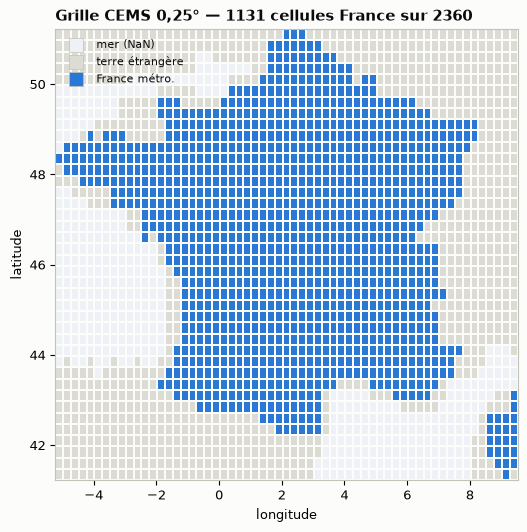

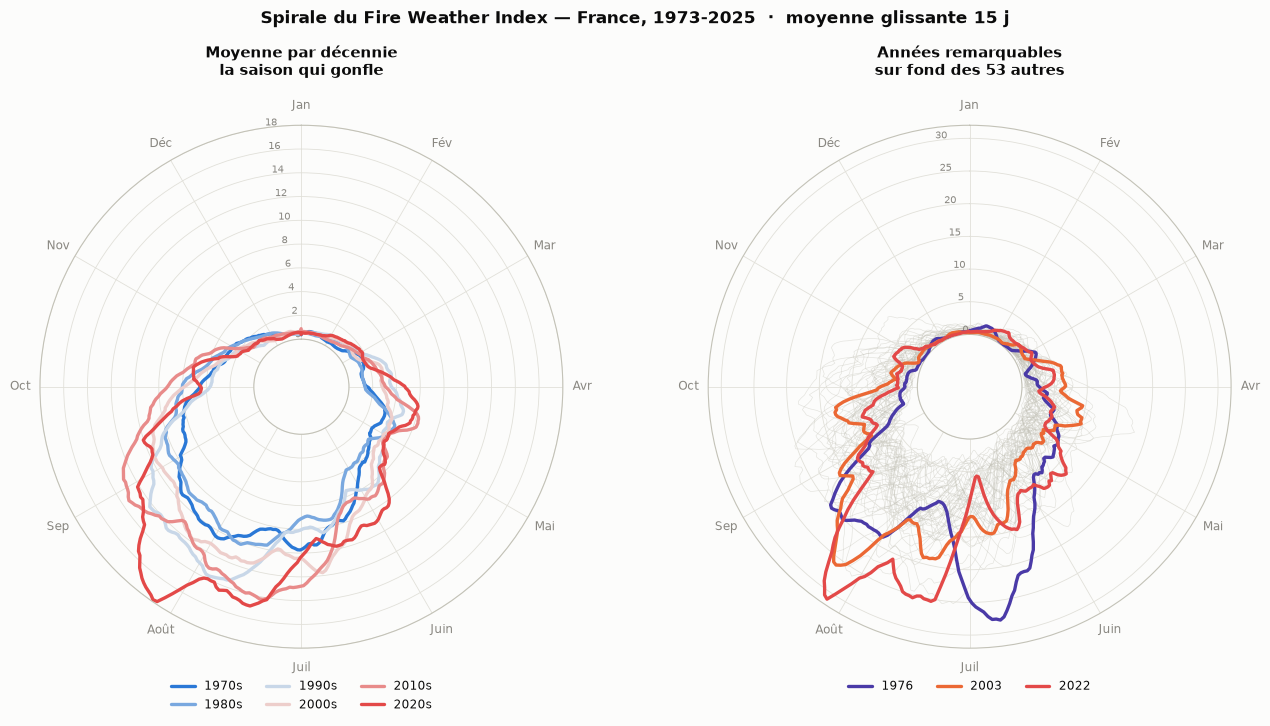

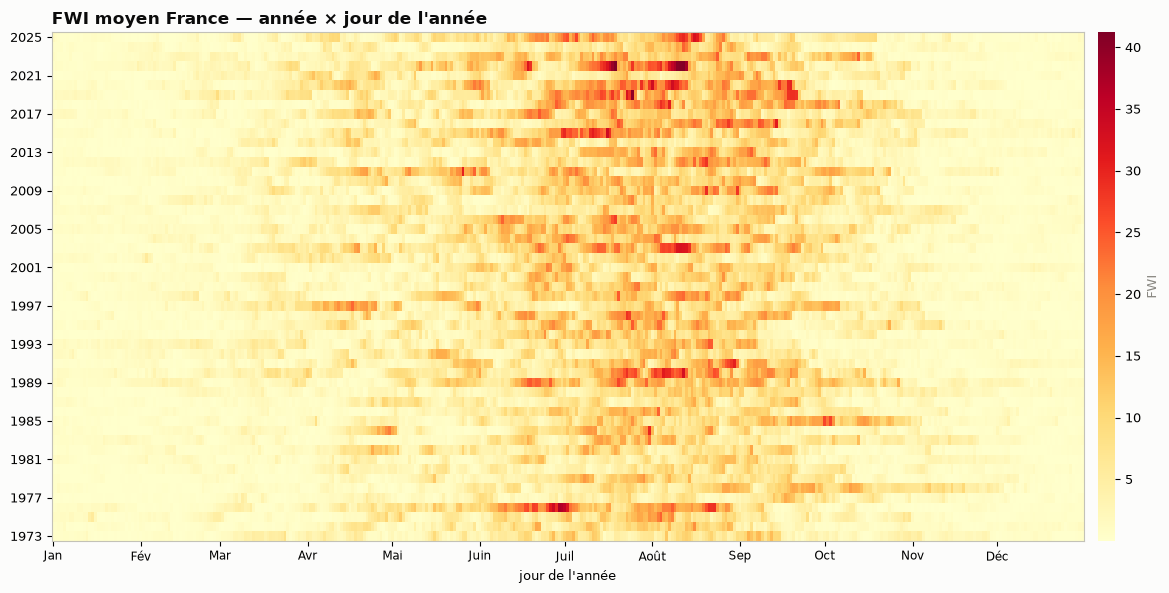

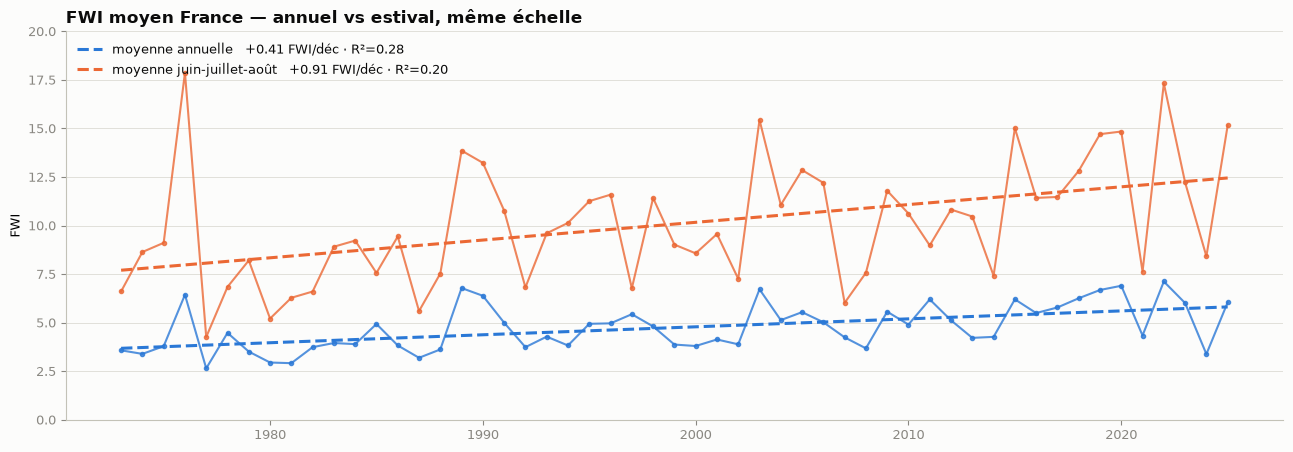

In [11]:
"""CELLULE 2 — Visuels. Dépend de la cellule 1 (SERIE, MASQUE_FR, MER, LATS, LONS)."""
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

# Palette années : bleu (passé) → rouge (présent) — convention de la spirale climatique
CMAP_ANNEES = LinearSegmentedColormap.from_list("annees", ["#2a78d6", "#f0efec", "#e34948"])
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})

ANNEES = np.sort(SERIE.annee.unique())
NORM = Normalize(ANNEES.min(), ANNEES.max())
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

# Le FWI journalier brut est trop bruité pour une spirale (chaque année = un oursin).
# Les spirales climatiques utilisent des moyennes mensuelles ; ici 15 j centrés,
# calculés sur la série CONTINUE pour que les bords d'année se raccordent.
LISSE = SERIE.copy()
for c in ("bbox", "france"):
    LISSE[c] = LISSE[c].rolling(15, center=True, min_periods=1).mean()

# ════════════════════════════════════════════════════════════════
# FIG 1 — LE MASQUE : ce que « France » veut dire sur la grille
# ════════════════════════════════════════════════════════════════
carte = np.zeros(MER.shape, dtype=int)   # 0 = mer
carte[~MER] = 1                          # 1 = terre étrangère
carte[MASQUE_FR] = 2                     # 2 = France métropolitaine

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.pcolormesh(LONS, LATS, carte, cmap=ListedColormap(["#eef2f6", "#dcdbd4", "#2a78d6"]),
              norm=BoundaryNorm([0, 1, 2, 3], 3), edgecolors="#fcfcfb", linewidth=.35)
ax.set_title(f"Grille CEMS 0,25° — {MASQUE_FR.sum()} cellules France sur {MER.size}",
             fontsize=11, weight="bold", loc="left")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_aspect(1 / np.cos(np.deg2rad(46)))          # plate-carrée corrigée en latitude
for lab, c in [("mer (NaN)", "#eef2f6"), ("terre étrangère", "#dcdbd4"), ("France métro.", "#2a78d6")]:
    ax.scatter([], [], s=90, marker="s", c=c, edgecolor="#c3c2b7", linewidth=.5, label=lab)
ax.legend(loc="upper left", frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 2 — SPIRALE CIRCULAIRE : bbox entière vs France seule
# ════════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════════
# FIG 2 — SPIRALE : décennies + années remarquables
# ════════════════════════════════════════════════════════════════
CM_DEC = LinearSegmentedColormap.from_list("dec", ["#2a78d6", "#f0efec", "#e34948"])

# 53 boucles individuelles = illisible. On agrège par décennie : 6 courbes suivables.
SP = SERIE.copy()
SP["lisse"] = SP.france.rolling(15, center=True, min_periods=1).mean()
SP["dec"] = (SP.annee // 10) * 10
TH = lambda doy: 2 * np.pi * (np.asarray(doy) - 1) / 365.25

def cadre(ax, titre, rorigin, rmax):
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)   # Jan en haut, sens horaire
    ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
    ax.set_xticklabels(MOIS, fontsize=8.5, color=MUTED)
    ax.set_rmax(rmax)
    ax.set_rorigin(rorigin)        # ← trou central : sans lui, tout converge en un nœud
    ax.set_rlabel_position(352)    # ← secteur déc-jan, le plus creux (FWI ≈ 0,6)
    ax.tick_params(axis="y", labelsize=7, colors=MUTED)
    ax.grid(color=GRID, lw=.6)
    ax.set_title(titre, fontsize=10.5, weight="bold", pad=18)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.8), subplot_kw={"projection": "polar"})

# ── GAUCHE : la tendance, décennie par décennie ──
decs = sorted(SP.dec.unique())
for i, dc in enumerate(decs):
    p = SP[SP.dec == dc].groupby("doy").lisse.mean()
    axes[0].plot(TH(p.index), p.values, color=CM_DEC(i / (len(decs) - 1)),
                 lw=2.4, solid_capstyle="round", label=f"{dc}s")
cadre(axes[0], "Moyenne par décennie\nla saison qui gonfle", rorigin=-4, rmax=18)
# légendes SOUS les panneaux : sur les côtés elles se posaient sur « Avr » / « Oct »
axes[0].legend(frameon=False, fontsize=8.5, ncol=3, loc="upper center",
               bbox_to_anchor=(.5, -.04))

# ── DROITE : les années extrêmes sur fond de toutes les autres ──
VEDETTES = {1976: "#4a3aa7", 2003: "#eb6834", 2022: "#e34948"}
for an in np.sort(SP.annee.unique()):
    if an in VEDETTES:
        continue
    d = SP[SP.annee == an]
    axes[1].plot(TH(d.doy), d.lisse, color="#c3c2b7", lw=.45, alpha=.45, zorder=1)
for an, c in VEDETTES.items():
    d = SP[SP.annee == an]
    axes[1].plot(TH(d.doy), d.lisse, color=c, lw=2.4, zorder=3,
                 solid_capstyle="round", label=str(an))
cadre(axes[1], "Années remarquables\nsur fond des 53 autres", rorigin=-8, rmax=32)
axes[1].legend(frameon=False, fontsize=8.5, ncol=3, loc="upper center",
               bbox_to_anchor=(.5, -.04))

fig.suptitle("Spirale du Fire Weather Index — France, 1973-2025  ·  moyenne glissante 15 j",
             fontsize=12.5, weight="bold", y=1.02)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 3 — HEATMAP année × jour de l'année (France)
# ════════════════════════════════════════════════════════════════
pivot = SERIE[SERIE.doy <= 365].pivot_table(index="annee", columns="doy", values="france")

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap="YlOrRd", shading="nearest")
ax.set_title("FWI moyen France — année × jour de l'année", fontsize=12, weight="bold", loc="left")
ax.set_xlabel("jour de l'année")
ax.set_xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]); ax.set_xticklabels(MOIS, fontsize=8.5)
ax.set_yticks(ANNEES[::4])
cb = fig.colorbar(im, ax=ax, pad=.012, aspect=30)
cb.set_label("FWI", fontsize=9, color=MUTED); cb.outline.set_visible(False)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 4 — ÉVOLUTION TEMPORELLE
# ════════════════════════════════════════════════════════════════

# ── RÉGRESSION LINÉAIRE (réutilisé par la cellule 4) ──
def tendance(x, y):
    """Régression OLS. Retourne (pente, ordonnée, R², droite(x)).
    numpy seul — scipy n'est pas installé, donc pas de p-value."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    a, b = np.polyfit(x, y, 1)
    ss_res = ((y - (a * x + b)) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
    return a, b, r2, (lambda xx: a * np.asarray(xx, float) + b)

def eq_txt(a, b, r2, unite=""):
    """Équation + R² + pente par décennie (plus lisible que par an)."""
    signe = "+" if b >= 0 else "−"
    return (f"y = {a:+.4f}·x {signe} {abs(b):.1f}\n"
            f"R² = {r2:.3f}\n"
            f"pente = {a*10:+.2f} {unite}/décennie")

BOITE = dict(boxstyle="round,pad=0.45", facecolor="#fcfcfb",
             edgecolor="#e1e0d9", linewidth=.9, alpha=.93)

# ════════════════════════════════════════════════════════════════
# FIG 4 — ÉVOLUTION TEMPORELLE, MÊME ÉCHELLE + RÉGRESSION
# ════════════════════════════════════════════════════════════════
annuel = SERIE.groupby("annee").france.mean()
ete    = SERIE[SERIE.date.dt.month.isin([6, 7, 8])].groupby("annee").france.mean()

fig, a = plt.subplots(figsize=(13, 4.6))
for s, c, lab in [(annuel, "#2a78d6", "moyenne annuelle"),
                  (ete,    "#eb6834", "moyenne juin-juillet-août")]:
    a.plot(s.index, s.values, lw=1.5, color=c, marker="o", ms=3, alpha=.8)
    pente, ord0, r2, droite = tendance(s.index, s.values)
    a.plot(s.index, droite(s.index), lw=2.2, color=c, ls="--", zorder=5,
           label=f"{lab}   {pente*10:+.2f} FWI/déc · R²={r2:.2f}")
a.set_ylim(0, 20); a.set_ylabel("FWI")
a.set_title("FWI moyen France — annuel vs estival, même échelle",
            fontsize=12, weight="bold", loc="left")
a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
a.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

In [7]:
"""CELLULE 3 — Extraction étendue : les 8 indices + cartes d'été + saison.
Dépend de la cellule 1 (CEMS, MASQUE_FR, MER, LATS, LONS). Une seule passe."""
import xarray as xr, numpy as np, pandas as pd
import warnings

IDX = {"fwinx": "FWI", "ffmcode": "FFMC", "dufmcode": "DMC", "drtcode": "DC",
       "fbupinx": "BUI", "infsinx": "ISI", "kbdi": "KBDI", "ercnfdr": "ERC"}
# Seuils officiels EFFIS (Plan.md §4.4)
SEUILS = {"Très faible": 0, "Faible": 5.2, "Moyen": 11.2, "Élevé": 21.3,
          "Très élevé": 38, "Extrême": 50}
COUL_EFFIS = ["#84F07F", "#FFEB3C", "#FFB00C", "#FA4F00", "#B40000", "#280923"]

morceaux, saison, ete_dec = [], [], {}
ete_cumul = np.zeros(MER.shape); ete_n = 0

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)   # nanmean sur la mer = All-NaN slice
    for f in CEMS:
        an = int(f.stem.split("_")[-1])
        with xr.open_dataset(f) as ds:
            t = pd.to_datetime(ds.valid_time.values)

            # (a) les 8 indices en moyenne France journalière
            d = {"date": t}
            for v, nom in IDX.items():
                d[nom] = np.nanmean(np.where(MASQUE_FR, ds[v].values, np.nan), axis=(1, 2))
            morceaux.append(pd.DataFrame(d))

            fwi = ds.fwinx.values                                  # (t, lat, lon)

            # (b) carte du FWI moyen estival (JJA) — cumul global + par décennie
            jja = np.isin(t.month, [6, 7, 8])
            carte_an = np.nanmean(fwi[jja], axis=0)
            ete_cumul += np.nan_to_num(carte_an); ete_n += 1
            dec = (an // 10) * 10
            s, n = ete_dec.get(dec, (np.zeros(MER.shape), 0))
            ete_dec[dec] = (s + np.nan_to_num(carte_an), n + 1)

            # (c) longueur de saison : jours/an au-dessus de chaque seuil, moyenne sur les cellules FR
            for nom, s_val in SEUILS.items():
                if s_val == 0:
                    continue
                cnt = (fwi > s_val).sum(axis=0)                    # NaN > s -> False, donc mer = 0
                saison.append({"annee": an, "classe": nom, "seuil": s_val,
                               "jours": float(cnt[MASQUE_FR].mean())})

SERIE8 = pd.concat(morceaux, ignore_index=True).sort_values("date").reset_index(drop=True)
SERIE8["annee"] = SERIE8.date.dt.year
SERIE8["doy"]   = SERIE8.date.dt.dayofyear

CARTE_ETE = np.where(MASQUE_FR, ete_cumul / ete_n, np.nan)
CARTES_DEC = {d: np.where(MASQUE_FR, s / n, np.nan) for d, (s, n) in sorted(ete_dec.items())}
SAISON = pd.DataFrame(saison)

print(f"✅ SERIE8   : {SERIE8.shape[0]:,} jours × {len(IDX)} indices")
print(f"✅ CARTE_ETE: FWI moyen JJA, {ete_n} étés, {np.isfinite(CARTE_ETE).sum()} cellules FR")
print(f"✅ CARTES_DEC: {list(CARTES_DEC)}")
print(f"✅ SAISON   : {SAISON.shape[0]} lignes ({SAISON.classe.nunique()} classes × {SAISON.annee.nunique()} ans)")
print()
print(SERIE8[list(IDX.values())].describe().loc[["mean", "min", "max"]].round(1).to_string())

✅ SERIE8   : 19,358 jours × 8 indices
✅ CARTE_ETE: FWI moyen JJA, 53 étés, 1131 cellules FR
✅ CARTES_DEC: [1970, 1980, 1990, 2000, 2010, 2020]
✅ SAISON   : 265 lignes (5 classes × 53 ans)

       FWI  FFMC    DMC     DC    BUI   ISI  KBDI   ERC
mean   4.7  67.3   14.0  169.9   20.5   2.5   3.9   2.4
min    0.0  19.7    0.0    2.5    0.1   0.0   0.0   0.0
max   41.2  93.9  111.3  568.4  133.2  16.1  33.1  11.6


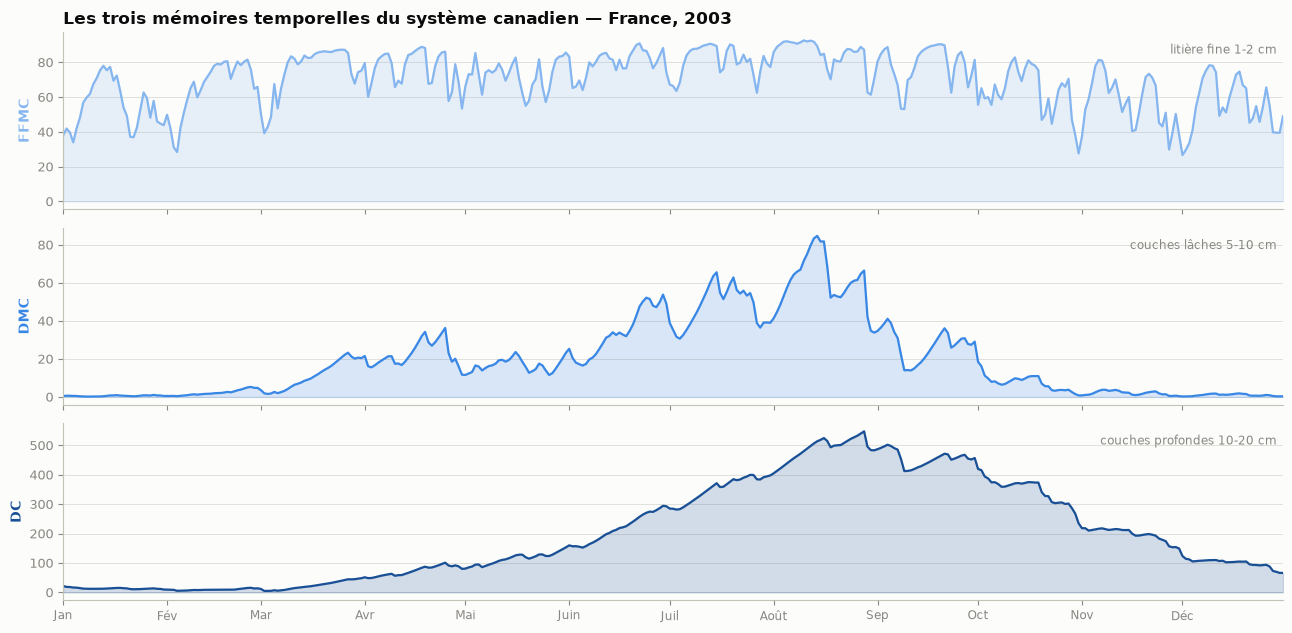

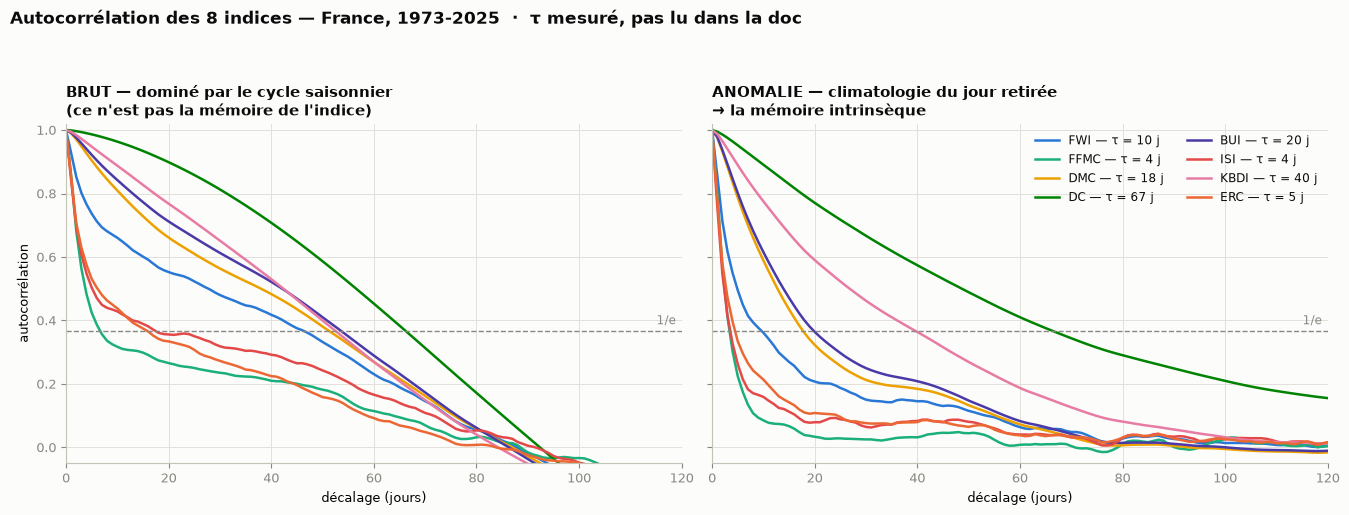

τ à 1/e  (brut → anomalie)  [doc : FFMC ~1 j · DMC 12 j · DC 52 j]
   FFMC    7 j →   4 j
   ISI    18 j →   4 j
   ERC    16 j →   5 j
   FWI    47 j →  10 j
   DMC    52 j →  18 j
   BUI    54 j →  20 j
   KBDI   53 j →  40 j
   DC     67 j →  67 j
⚠️  τ(anomalie) reste au-dessus de la doc car on moyenne sur 1 131 cellules :
    la moyenne spatiale lisse le jour-le-jour. Sur une cellule seule, le FFMC serait plus court.


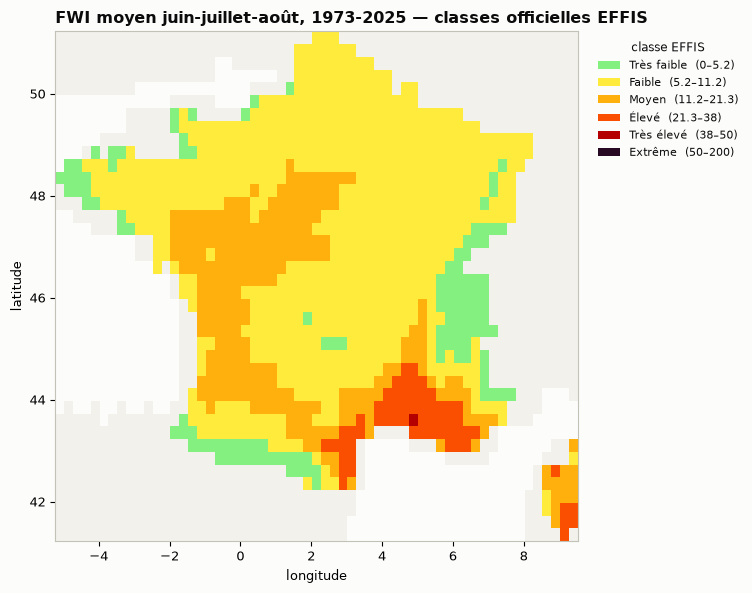

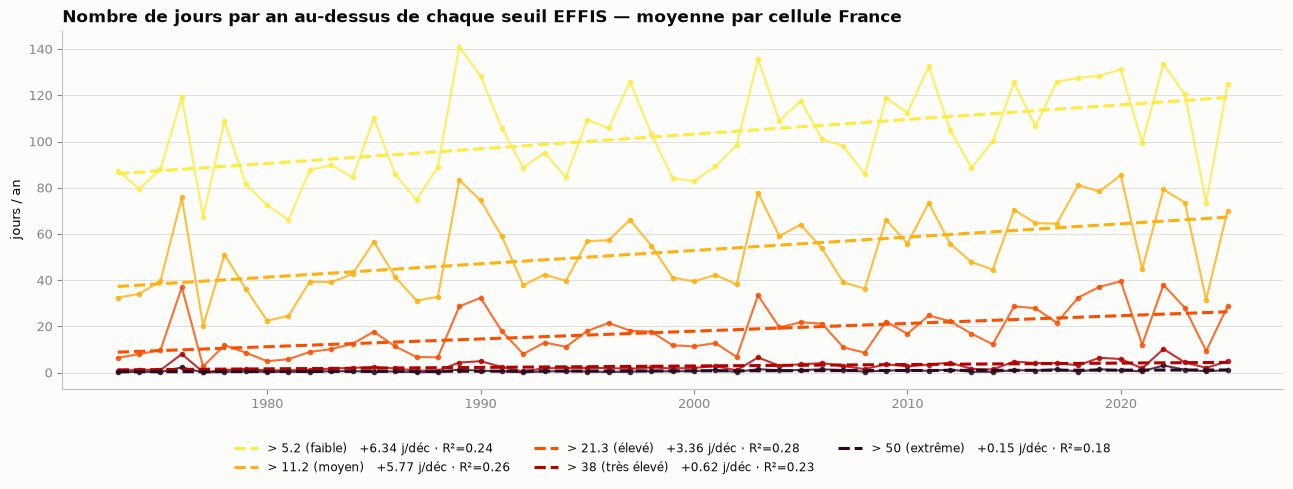

Régressions — jours/an au-dessus du seuil (x = année)
   Faible       y = +0.6342·x −  1165.1   R² = 0.244   +6.34 j/déc
   Moyen        y = +0.5773·x −  1101.7   R² = 0.261   +5.77 j/déc
   Élevé        y = +0.3358·x −   653.7   R² = 0.277   +3.36 j/déc
   Très élevé   y = +0.0623·x −   121.7   R² = 0.231   +0.62 j/déc
   Extrême      y = +0.0152·x −    29.7   R² = 0.181   +0.15 j/déc


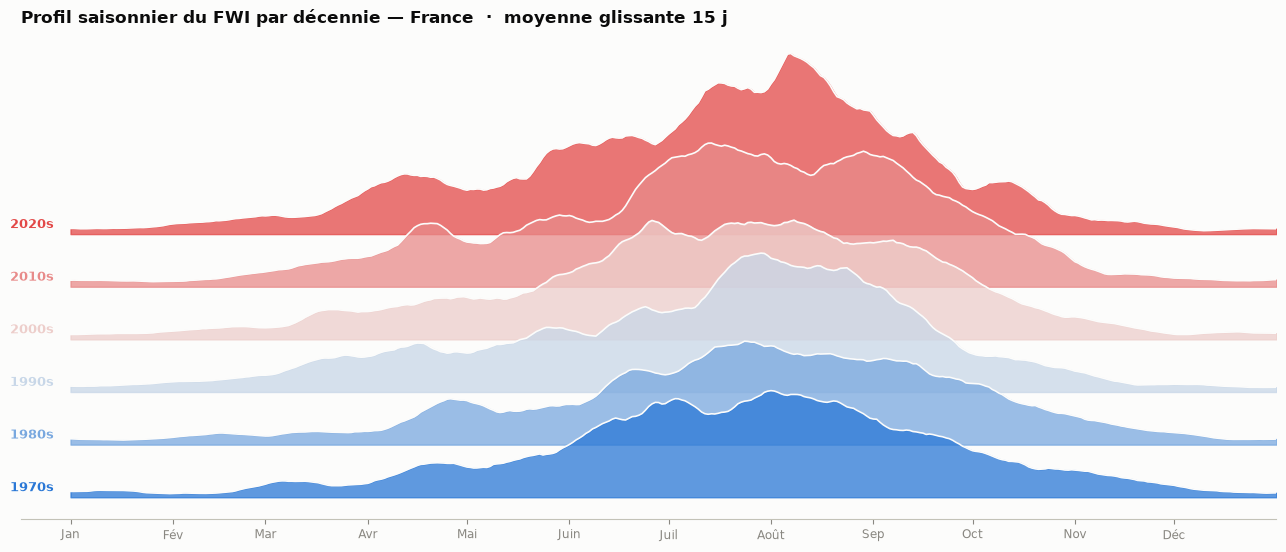

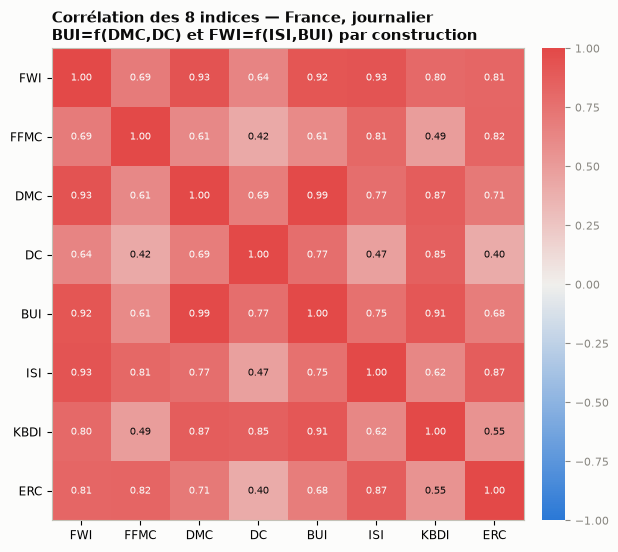

moyenne annuelle   y = +0.0410·x − 77.2   R² = 0.282
maximum annuel     y = +0.1863·x − 347.8   R² = 0.195


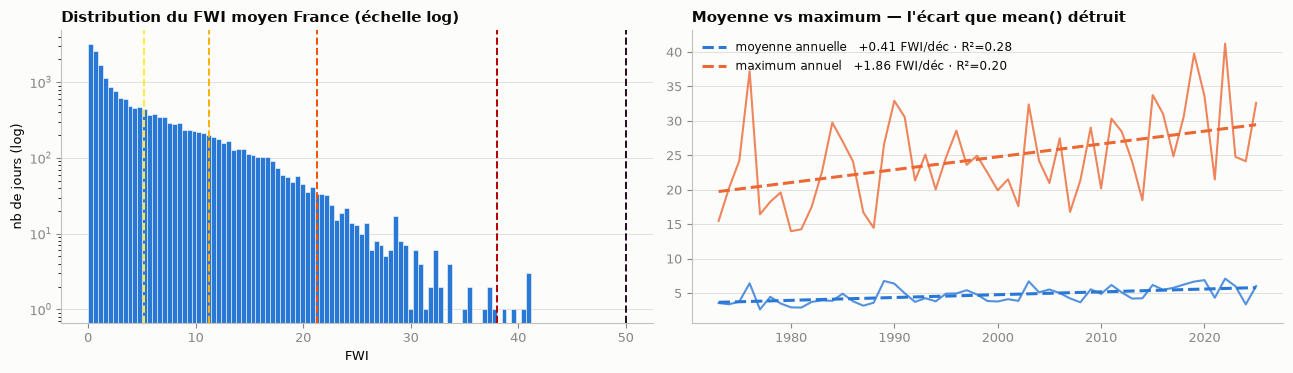

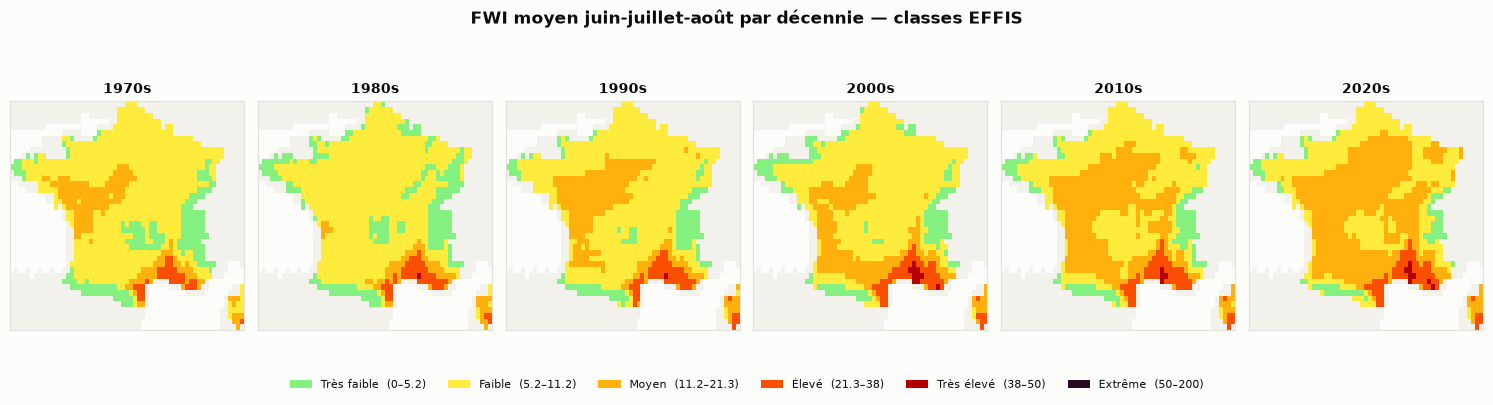

In [9]:
"""CELLULE 4 — Les 8 figures. Dépend des cellules 1 et 3."""
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
from matplotlib.patches import Patch

INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 9, "axes.edgecolor": "#c3c2b7", "text.color": INK})
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]
DEB_MOIS = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
ASPECT = 1 / np.cos(np.deg2rad(46))

# ════════════════════════════════════════════════════════════════
# FIG 5 — LES 3 MÉMOIRES TEMPORELLES (FFMC 1j · DMC 12j · DC 52j)
# ════════════════════════════════════════════════════════════════
# Profondeur de mémoire encodée par la profondeur du bleu (rampe séquentielle).
AN_DEMO = 2003
d = SERIE8[SERIE8.annee == AN_DEMO]
memo = [("FFMC", "#86b6ef", "litière fine 1-2 cm"),
        ("DMC",  "#3987e5", "couches lâches 5-10 cm"),
        ("DC",   "#184f95", "couches profondes 10-20 cm")]

fig, axes = plt.subplots(3, 1, figsize=(13, 6.4), sharex=True)
for ax, (nom, coul, sous) in zip(axes, memo):
    ax.fill_between(d.doy, d[nom], color=coul, alpha=.18)
    ax.plot(d.doy, d[nom], color=coul, lw=1.6)
    ax.set_ylabel(nom, fontsize=10, weight="bold", color=coul)
    ax.text(.995, .88, sous, transform=ax.transAxes, ha="right", fontsize=8.5, color=MUTED)
    ax.grid(axis="y", color=GRID, lw=.7); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=MUTED)
axes[0].set_title(f"Les trois mémoires temporelles du système canadien — France, {AN_DEMO}",
                  fontsize=12, weight="bold", loc="left")
axes[-1].set_xticks(DEB_MOIS); axes[-1].set_xticklabels(MOIS, fontsize=8.5)
axes[-1].set_xlim(1, 365)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 6 — AUTOCORRÉLATION : on MESURE les latences
# ════════════════════════════════════════════════════════════════
def acf(x, nlags):
    x = np.asarray(x, float); x = x - x.mean()
    den = (x * x).sum()
    return np.array([1.0] + [(x[:-k] * x[k:]).sum() / den for k in range(1, nlags + 1)])

def tau_1e(a):
    s = np.where(a < 1 / np.e)[0]
    return int(s[0]) if len(s) else None

NLAGS = 120
NOMS8 = ["FWI", "FFMC", "DMC", "DC", "BUI", "ISI", "KBDI", "ERC"]
SLOTS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INV_E = 1 / np.e

# ⚠️ Sur la série BRUTE, l'ACF ne mesure PAS la mémoire de l'indice : elle est
# dominée par le cycle saisonnier (toutes les courbes décroissent ensemble vers 0
# à ~90 j = un quart de cycle annuel). Il faut retirer la climatologie du jour de
# l'année pour isoler la mémoire intrinsèque.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
mesures = {}
for nom, coul in zip(NOMS8, SLOTS):
    brute = acf(SERIE8[nom].values, NLAGS)
    clim  = SERIE8.groupby("doy")[nom].transform("mean")
    anom  = acf((SERIE8[nom] - clim).values, NLAGS)
    mesures[nom] = (tau_1e(brute), tau_1e(anom))
    axes[0].plot(range(NLAGS + 1), brute, color=coul, lw=1.8)
    axes[1].plot(range(NLAGS + 1), anom,  color=coul, lw=1.8,
                 label=f"{nom} — τ = {tau_1e(anom)} j")

axes[0].set_title("BRUT — dominé par le cycle saisonnier\n(ce n'est pas la mémoire de l'indice)",
                  fontsize=10.5, weight="bold", loc="left")
axes[1].set_title("ANOMALIE — climatologie du jour retirée\n→ la mémoire intrinsèque",
                  fontsize=10.5, weight="bold", loc="left")
axes[1].legend(frameon=False, fontsize=8.5, ncol=2)
for ax in axes:
    ax.axhline(INV_E, color=MUTED, ls="--", lw=1)
    ax.text(NLAGS * .99, INV_E + .02, "1/e", ha="right", fontsize=8.5, color=MUTED)
    ax.set_xlabel("décalage (jours)")
    ax.set_xlim(0, NLAGS); ax.set_ylim(-.05, 1.02)
    ax.grid(color=GRID, lw=.7); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False); ax.tick_params(colors=MUTED)
axes[0].set_ylabel("autocorrélation")
fig.suptitle("Autocorrélation des 8 indices — France, 1973-2025  ·  τ mesuré, pas lu dans la doc",
             fontsize=12, weight="bold", x=.005, ha="left", y=1.06)
plt.tight_layout(); plt.show()

print("τ à 1/e  (brut → anomalie)  [doc : FFMC ~1 j · DMC 12 j · DC 52 j]")
for n, (b, a) in sorted(mesures.items(), key=lambda kv: kv[1][1] or 999):
    print(f"   {n:5s} {b:3d} j → {a:3d} j")
print("⚠️  τ(anomalie) reste au-dessus de la doc car on moyenne sur 1 131 cellules :")
print("    la moyenne spatiale lisse le jour-le-jour. Sur une cellule seule, le FFMC serait plus court.")

# ════════════════════════════════════════════════════════════════
# FIG 7 — CARTE FWI ESTIVAL, COULEURS OFFICIELLES EFFIS
# ════════════════════════════════════════════════════════════════
BORNES = [0, 5.2, 11.2, 21.3, 38, 50, 200]
NOMS_CL = ["Très faible", "Faible", "Moyen", "Élevé", "Très élevé", "Extrême"]
CMAP_EFFIS = ListedColormap(COUL_EFFIS)
NORM_EFFIS = BoundaryNorm(BORNES, len(COUL_EFFIS))
LEG_EFFIS = [Patch(facecolor=c, label=f"{n}  ({BORNES[i]:g}–{BORNES[i+1]:g})")
             for i, (c, n) in enumerate(zip(COUL_EFFIS, NOMS_CL))]

fig, ax = plt.subplots(figsize=(8.2, 6))
ax.pcolormesh(LONS, LATS, np.where(MER, np.nan, 0), cmap=ListedColormap(["#f2f1ec"]))  # fond terre
ax.pcolormesh(LONS, LATS, CARTE_ETE, cmap=CMAP_EFFIS, norm=NORM_EFFIS)
ax.set_title("FWI moyen juin-juillet-août, 1973-2025 — classes officielles EFFIS",
             fontsize=11.5, weight="bold", loc="left")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect(ASPECT)
# légende HORS du cadre : posée dessus, elle masquait la Bretagne
ax.legend(handles=LEG_EFFIS, loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False,
          fontsize=8, title="classe EFFIS", title_fontsize=8.5)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 8 — LONGUEUR DE SAISON : jours/an au-dessus de chaque seuil
# ════════════════════════════════════════════════════════════════
piv = SAISON.pivot(index="annee", columns="classe", values="jours")
ordre = ["Faible", "Moyen", "Élevé", "Très élevé", "Extrême"]
piv = piv[[c for c in ordre if c in piv.columns]]

fig, ax = plt.subplots(figsize=(13, 5))
eqs = []
for c, coul in zip(piv.columns, COUL_EFFIS[1:]):
    ax.plot(piv.index, piv[c], lw=1.5, color=coul, marker="o", ms=3, alpha=.8)
    pente, ord0, r2, droite = tendance(piv.index, piv[c].values)
    # 5 boîtes d'équation seraient illisibles : pente + R² vont dans la légende
    ax.plot(piv.index, droite(piv.index), lw=2.2, color=coul, ls="--", zorder=5,
            label=f"> {SEUILS[c]:g} ({c.lower()})   {pente*10:+.2f} j/déc · R²={r2:.2f}")
    eqs.append((c, pente, ord0, r2))
ax.set_title("Nombre de jours par an au-dessus de chaque seuil EFFIS — moyenne par cellule France",
             fontsize=12, weight="bold", loc="left")
ax.set_ylabel("jours / an")
ax.grid(axis="y", color=GRID, lw=.7); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False); ax.tick_params(colors=MUTED)
# légende SOUS le graphe : à l'intérieur elle masquait la courbe « faible »
ax.legend(frameon=False, fontsize=8.5, ncol=3, loc="upper center",
          bbox_to_anchor=(.5, -.12))
plt.tight_layout(); plt.show()

print("Régressions — jours/an au-dessus du seuil (x = année)")
for c, a, b, r2 in eqs:
    print(f"   {c:12s} y = {a:+.4f}·x {'+' if b >= 0 else '−'} {abs(b):7.1f}   R² = {r2:.3f}   {a*10:+.2f} j/déc")

# ════════════════════════════════════════════════════════════════
# FIG 9 — RIDGELINE PAR DÉCENNIE
# ════════════════════════════════════════════════════════════════
SERIE8["dec"] = (SERIE8.annee // 10) * 10
decs = sorted(SERIE8.dec.unique())
cmap_dec = LinearSegmentedColormap.from_list("d", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(13, 5.6))
DECAL = 5.2
for i, dc in enumerate(decs):
    prof = (SERIE8[SERIE8.dec == dc].groupby("doy").FWI.mean()
            .rolling(15, center=True, min_periods=1).mean())
    y = prof.values + i * DECAL
    coul = cmap_dec(i / (len(decs) - 1))
    ax.fill_between(prof.index, i * DECAL, y, color=coul, alpha=.75, zorder=len(decs) - i)
    ax.plot(prof.index, y, color="#fcfcfb", lw=1.2, zorder=len(decs) - i)
    ax.text(-4, i * DECAL + .6, f"{dc}s", ha="right", fontsize=9, weight="bold", color=coul)
ax.set_title("Profil saisonnier du FWI par décennie — France  ·  moyenne glissante 15 j",
             fontsize=12, weight="bold", loc="left")
ax.set_xticks(DEB_MOIS); ax.set_xticklabels(MOIS, fontsize=8.5)
ax.set_xlim(-14, 366); ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(colors=MUTED)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 10 — CORRÉLATIONS : les dépendances ALGÉBRIQUES entre indices
# ════════════════════════════════════════════════════════════════
noms = ["FWI", "FFMC", "DMC", "DC", "BUI", "ISI", "KBDI", "ERC"]
C = SERIE8[noms].corr()
# Diverging bleu↔rouge, gris neutre au 0 — la corrélation A un vrai zéro
CMAP_DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(C, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(noms))); ax.set_xticklabels(noms, fontsize=8.5)
ax.set_yticks(range(len(noms))); ax.set_yticklabels(noms, fontsize=8.5)
for i in range(len(noms)):
    for j in range(len(noms)):
        v = C.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="#fcfcfb" if abs(v) > .6 else INK)
ax.set_title("Corrélation des 8 indices — France, journalier\nBUI=f(DMC,DC) et FWI=f(ISI,BUI) par construction",
             fontsize=10.5, weight="bold", loc="left")
cb = fig.colorbar(im, ax=ax, fraction=.046, pad=.03); cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, colors=MUTED)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 11 — QUEUE LOURDE DU FWI (échelle log)
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(SERIE8.FWI, bins=90, color="#2a78d6", edgecolor="#fcfcfb", linewidth=.4)
ax[0].set_yscale("log")
ax[0].set_title("Distribution du FWI moyen France (échelle log)", fontsize=11, weight="bold", loc="left")
ax[0].set_xlabel("FWI"); ax[0].set_ylabel("nb de jours (log)")

for s, c, n in zip(list(SEUILS.values())[1:], COUL_EFFIS[1:], list(SEUILS)[1:]):
    ax[0].axvline(s, color=c, lw=1.4, ls="--")

moy = SERIE8.groupby("annee").FWI.mean()
mx  = SERIE8.groupby("annee").FWI.max()
for s, coul, lab in [(moy, "#2a78d6", "moyenne annuelle"), (mx, "#eb6834", "maximum annuel")]:
    ax[1].plot(s.index, s.values, lw=1.5, color=coul, alpha=.8)
    pente, ord0, r2, droite = tendance(s.index, s.values)
    ax[1].plot(s.index, droite(s.index), lw=2.2, color=coul, ls="--", zorder=5,
               label=f"{lab}   {pente*10:+.2f} FWI/déc · R²={r2:.2f}")
    print(f"{lab:18s} y = {pente:+.4f}·x {'+' if ord0 >= 0 else '−'} {abs(ord0):.1f}   R² = {r2:.3f}")
ax[1].set_title("Moyenne vs maximum — l'écart que mean() détruit", fontsize=11, weight="bold", loc="left")
ax[1].legend(frameon=False, fontsize=8.5, loc="upper left")
for a in ax:
    a.grid(axis="y", color=GRID, lw=.7); a.set_axisbelow(True)
    a.spines[["top", "right"]].set_visible(False); a.tick_params(colors=MUTED)
plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 12 — PETITS MULTIPLES : FWI estival par décennie
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, len(CARTES_DEC), figsize=(15, 3.4))
for ax, (dc, carte) in zip(axes, CARTES_DEC.items()):
    ax.pcolormesh(LONS, LATS, np.where(MER, np.nan, 0), cmap=ListedColormap(["#f2f1ec"]))
    ax.pcolormesh(LONS, LATS, carte, cmap=CMAP_EFFIS, norm=NORM_EFFIS)
    ax.set_title(f"{dc}s", fontsize=10, weight="bold")
    ax.set_aspect(ASPECT); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#e1e0d9")
fig.suptitle("FWI moyen juin-juillet-août par décennie — classes EFFIS",
             fontsize=12, weight="bold", y=1.06)
fig.legend(handles=LEG_EFFIS, loc="lower center", bbox_to_anchor=(.5, -.09),
           ncol=6, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()